Dataset shape: 891
Age_filled: μ=29.11 σ=13.30 Shapiro p=0.0000

Pclass (Uniform):
  Pclass 1: 0.242 (vs 0.333)
  Pclass 2: 0.207 (vs 0.333)
  Pclass 3: 0.551 (vs 0.333)

Weibull(Fare): shape=0.93 scale=30.67
P(Age<=50|Normal): 0.9418
P(Fare<=50|Weibull): 0.7924


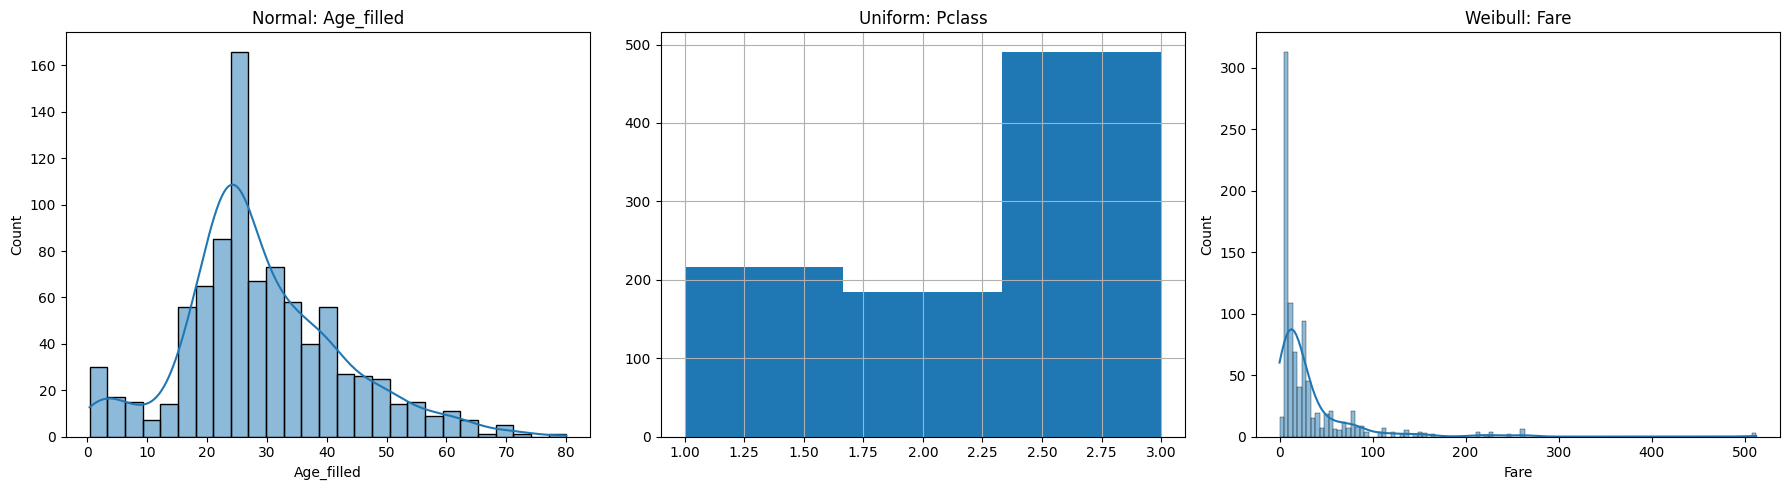

In [12]:
# Data Science Lab Assignment 6: Continuous Probability Distributions
# Dataset: Preprocessed Titanic [web:21]

import pandas as pd
import numpy as np
from scipy.stats import norm, weibull_min, shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Load/preprocess
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Age_filled'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df_clean = df.dropna(subset=['Age_filled', 'Fare'])

mu_age = df_clean['Age_filled'].mean()
sigma_age = df_clean['Age_filled'].std()
pclass_vc = df_clean['Pclass'].value_counts(normalize=True)
shape_wb, loc_wb, scale_wb = weibull_min.fit(df_clean['Fare'], floc=0)

age_sample = df_clean['Age_filled'].sample(min(5000, len(df_clean)))
shap_p = shapiro(age_sample)[1]

print("Dataset shape:", len(df_clean))
print("Age_filled: μ=%.2f σ=%.2f Shapiro p=%.4f" % (mu_age, sigma_age, shap_p))
print("\nPclass (Uniform):")
for pc in [1,2,3]:
    print("  Pclass %d: %.3f (vs 0.333)" % (pc, pclass_vc.get(pc,0)))
print("\nWeibull(Fare): shape=%.2f scale=%.2f" % (shape_wb, scale_wb))
print("P(Age<=50|Normal): %.4f" % norm.cdf(50, mu_age, sigma_age))
print("P(Fare<=50|Weibull): %.4f" % weibull_min.cdf(50, shape_wb, loc=loc_wb, scale=scale_wb))

# Plots
fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.histplot(df_clean['Age_filled'], kde=True, ax=axes[0]); axes[0].set_title('Normal: Age_filled')
df_clean['Pclass'].hist(bins=3, ax=axes[1]); axes[1].set_title('Uniform: Pclass')
sns.histplot(df_clean['Fare'], kde=True, ax=axes[2]); axes[2].set_title('Weibull: Fare')
plt.tight_layout()
plt.show()
